# Display norm

In [2]:
import torch
import json
import os

from data.ae_dataset import AEDataset
from torch import linalg as LA
import numpy as np
from matplotlib.pyplot import plot

In [3]:
rec_seq = torch.load("model_outputs/rec_seq_0724_204251_v9.pt")   # [10377, 10, 512]

In [6]:
all_norm_list = []
for seq in rec_seq:
    # seq: [10, 512]
    norm_list = []
    for emb in seq:
        # emb: [512]
        norm_list.append(LA.norm(emb).item())
    all_norm_list.append(norm_list)

In [28]:
len(all_norm_list)

10377

In [7]:
all_norm_list[0]

[0.9535671472549438,
 0.9414432048797607,
 0.020499056205153465,
 0.571505069732666,
 0.6649578213691711,
 0.6469458937644958,
 0.7069915533065796,
 0.6859124302864075,
 0.7175210118293762,
 0.7258670926094055]

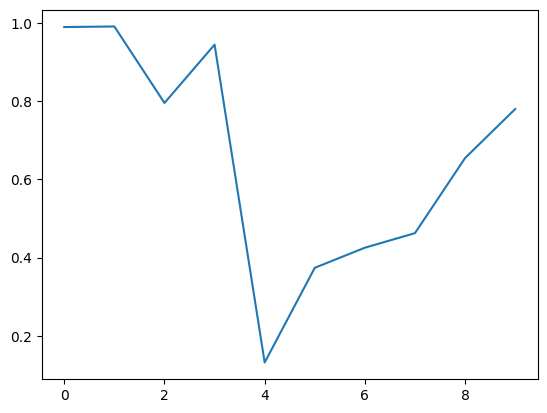

In [24]:
plot(range(10), all_norm_list[1230])

# Find closest parts embedding

In [25]:
# find the pad for ori, compute the 'mask'
eps = 0.2
threshold = 0.5

In [26]:
all_emb_path = os.path.join("./processed_data", "mean_pooled_emb.pt")
all_emb = torch.load(all_emb_path)   # [141245, 512]

In [27]:
all_md_path = os.path.join("./processed_data", "emb_idx_filtered.json")
with open(all_md_path, 'r') as fp:
    all_md = json.load(fp)   # .shape[0]=141245

In [39]:
def find_closest(emb):
    delta = all_emb - emb
    print(delta.shape)
    dist = LA.norm(delta, dim=1)
    print(dist.shape)
    idx = dist.argmin()
    print(dist[:10])
    print(idx)
    print(dist[idx])
    
    return idx

In [40]:
all_closest_emb_list = []
for i, seq in enumerate(rec_seq[:1, :, :]):
    closest_emb_list = []
    for j, rec_emb in enumerate(seq):
        if all_norm_list[i][j] < eps:
            break
        closest_emb_idx = find_closest(rec_emb)

torch.Size([141245, 512])
torch.Size([141245])
tensor([0.2975, 0.5402, 0.5407, 0.2975, 0.2975, 0.5407, 0.5603, 0.2968, 0.3466,
        0.3089], grad_fn=<SliceBackward0>)
tensor(125521)
tensor(0.1062, grad_fn=<SelectBackward0>)
torch.Size([141245, 512])
torch.Size([141245])
tensor([0.3662, 0.5016, 0.5033, 0.3662, 0.3662, 0.5033, 0.5258, 0.3948, 0.4106,
        0.3143], grad_fn=<SliceBackward0>)
tensor(131605)
tensor(0.1648, grad_fn=<SelectBackward0>)
